# Problem 2: Computing Covariances from Data

In [58]:
# Import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any

# read in the data from the two files
imu_df = pd.read_csv("./imu1.csv")  # replace filepath with yours
vicon_df = pd.read_csv("./vi1.csv")  # replace filepath with yours

In [ ]:
# Display a preview of the data
with pd.option_context('display.expand_frame_repr', False):
    print("IMU Data:")
    print(imu_df.head())

    print("Vicon Data:")
    print(vicon_df.head())

IMU Data:
           Time  attitude_roll_radians  attitude_pitch_radians  attitude_yaw_radians  rotation_rate_x_rad_per_sec  rotation_rate_y_rad_per_sec  rotation_rate_z_rad_per_s  gravity_x_G  gravity_y_G  gravity_z_G  user_acc_x_G  user_acc_y_G  user_acc_z_G  magnetic_field_x_microteslas  magnetic_field_y_microteslas  magnetic_field_z_microteslas
0  1.528386e+09              -0.098336                0.412141              0.224581                    -0.598061                     0.991373                   0.558243    -0.089956    -0.400572    -0.911838      0.336615      0.136839     -0.407513                     13.448853                    -13.443630                    -35.590454
1  1.528386e+09              -0.095373                0.409146              0.226051                    -0.710377                     1.029620                   0.533786    -0.087359    -0.397823    -0.913275      0.324242      0.146572     -0.404438                     13.610510                    -13.4056

## Part 1: Exploring the Dataset

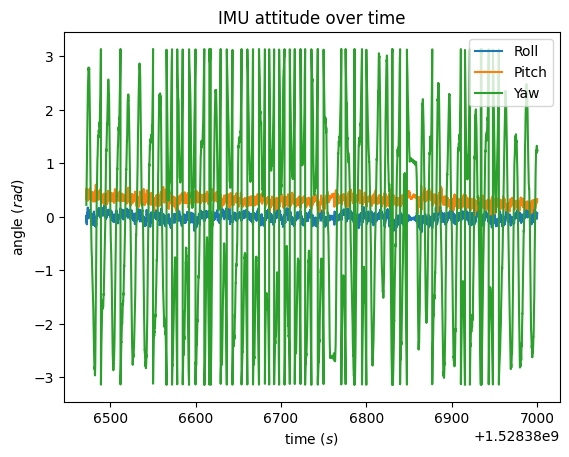

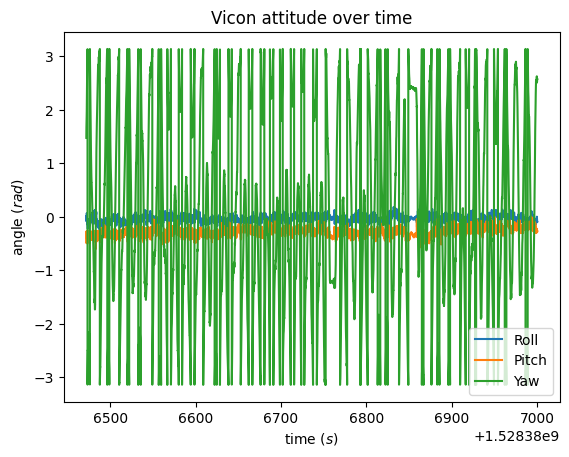

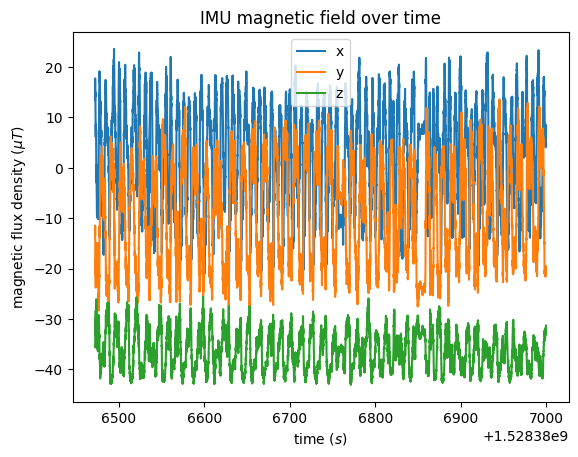

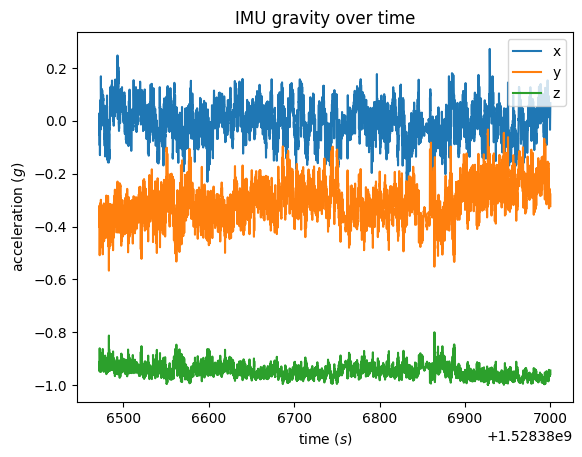

In [17]:
# Plot different readings over time
plt.plot(imu_df['Time'], imu_df['attitude_roll_radians'])
plt.plot(imu_df['Time'], imu_df['attitude_pitch_radians'])
plt.plot(imu_df['Time'], imu_df['attitude_yaw_radians'])

plt.title('IMU attitude over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'angle ($rad$)')
plt.legend(['Roll', 'Pitch', 'Yaw'])

plt.show()

plt.plot(vicon_df['Time'], vicon_df['roll'])
plt.plot(vicon_df['Time'], vicon_df['pitch'])
plt.plot(vicon_df['Time'], vicon_df['yaw'])

plt.title('Vicon attitude over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'angle ($rad$)')
plt.legend(['Roll', 'Pitch', 'Yaw'])

plt.show()

plt.plot(imu_df['Time'], imu_df['magnetic_field_x_microteslas'])
plt.plot(imu_df['Time'], imu_df['magnetic_field_y_microteslas'])
plt.plot(imu_df['Time'], imu_df['magnetic_field_z_microteslas'])

plt.title('IMU magnetic field over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'magnetic flux density ($\mu T$)')
plt.legend(['x', 'y', 'z'])

plt.show()

plt.plot(imu_df['Time'], imu_df['gravity_x_G'])
plt.plot(imu_df['Time'], imu_df['gravity_y_G'])
plt.plot(imu_df['Time'], imu_df['gravity_z_G'])

plt.title('IMU gravity over time')
plt.xlabel(r'time ($s$)')
plt.ylabel(r'acceleration ($g$)')
plt.legend(['x', 'y', 'z'])

plt.show()

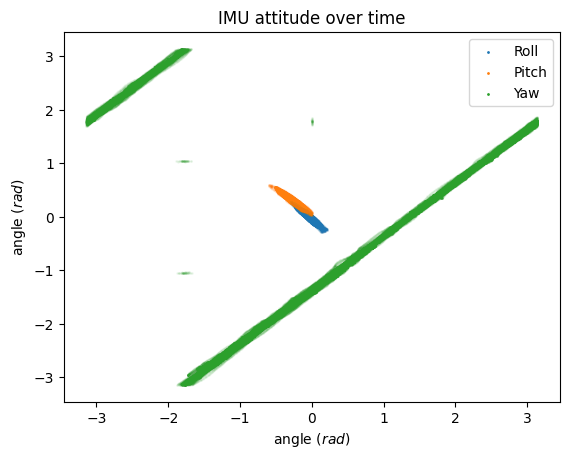

In [35]:
# Plot different readings compared to eachother
options = {
    's': 1,
    'alpha': 0.05,
}

plt.scatter(vicon_df['roll'], imu_df['attitude_roll_radians'], **options) # type: ignore
plt.scatter(vicon_df['pitch'], imu_df['attitude_pitch_radians'], **options) # type: ignore
plt.scatter(vicon_df['yaw'], imu_df['attitude_yaw_radians'], **options) # type: ignore

plt.title('IMU attitude over time')
plt.xlabel(r'angle ($rad$)')
plt.ylabel(r'angle ($rad$)')
legend = plt.legend(['Roll', 'Pitch', 'Yaw'])

for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1) # type: ignore
plt.show()

## Part B: Comparing IMU Axes

In [59]:
# Function to compute and print the covariance and correlation coefficient matrices for a list of columns in `imu_df`
def compute_and_print_cov_and_corrcoef(columns: list[str], name: str, numpy_printoptions: dict[str, Any] = {}):
    data = imu_df[columns].to_numpy()
    cov = np.cov(data, rowvar=False)
    corrcoef = np.corrcoef(data, rowvar=False)

    with np.printoptions(**numpy_printoptions):
        print(f'Covariance and correlation coefficient matrices for {name}\nCovariance matrix:\n{cov}\nCorrelation coefficient matrix:\n{corrcoef}\n')


In [68]:
# Compute the covariance and correlation coefficient matrices for various readings
compute_and_print_cov_and_corrcoef(
    ['user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G'], 
    'acceleration in all three axes (x, y, z)',
)
compute_and_print_cov_and_corrcoef(
    ['attitude_yaw_radians', 'attitude_pitch_radians', 'attitude_roll_radians'],
    'attitude in all three axes (yaw, pitch, roll)',
)
compute_and_print_cov_and_corrcoef(
    ['rotation_rate_x_rad_per_sec', 'rotation_rate_y_rad_per_sec', 'rotation_rate_z_rad_per_s'],
    'rate of rotation in all three axes (yaw, pitch roll)',
)
compute_and_print_cov_and_corrcoef(
    [
        'gravity_x_G', 'gravity_y_G', 'gravity_z_G', 
        'magnetic_field_x_microteslas', 'magnetic_field_y_microteslas', 'magnetic_field_z_microteslas',
        'user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G',
    ],
    'gravity, magnetic field, and acceleration for each of the three axes (x, y, z)',
    {
        'precision': 4,
        'suppress': True,
        'linewidth': 100,
    }
)
compute_and_print_cov_and_corrcoef(
    [
        'rotation_rate_x_rad_per_sec', 'rotation_rate_y_rad_per_sec', 'rotation_rate_z_rad_per_s', 
        'user_acc_x_G', 'user_acc_y_G', 'user_acc_z_G',
    ],
    'rate of rotation and acceleration for each of the three axes (x, y, z)',
    {
        'precision': 4,
        'suppress': True,
        'linewidth': 100,
    }
)


Covariance and correlation coefficient matrices for acceleration in all three axes (x, y, z)
Covariance matrix:
[[ 2.26456107e-02 -4.71148351e-03 -5.26712019e-05]
 [-4.71148351e-03  1.35404957e-02 -1.05112843e-03]
 [-5.26712019e-05 -1.05112843e-03  4.04986117e-02]]
Correlation coefficient matrix:
[[ 1.         -0.26905953 -0.00173925]
 [-0.26905953  1.         -0.04488678]
 [-0.00173925 -0.04488678  1.        ]]

Covariance and correlation coefficient matrices for attitude in all three axes (yaw, pitch, roll)
Covariance matrix:
[[ 3.20040253e+00  8.02045917e-03 -1.45880596e-04]
 [ 8.02045917e-03  5.64988258e-03 -7.82262882e-04]
 [-1.45880596e-04 -7.82262882e-04  4.69720699e-03]]
Correlation coefficient matrix:
[[ 1.          0.05964544 -0.0011898 ]
 [ 0.05964544  1.         -0.15184943]
 [-0.0011898  -0.15184943  1.        ]]

Covariance and correlation coefficient matrices for rate of rotation in all three axes (yaw, pitch roll)
Covariance matrix:
[[ 0.28665589 -0.0680202   0.08761712

## Part C: Comparing IMU with Vicon Ground Truth